In [84]:
%%capture
!pip install -r requirements.txt

In [89]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [10]:
!kaggle competitions download -c traveling-santa-2018-prime-paths

cities.csv.zip: Skipping, found more recently modified local copy (use --force to force download)
sample_submission.csv.zip: Skipping, found more recently modified local copy (use --force to force download)


In [11]:
df = pd.read_csv('cities.csv.zip', index_col='CityId')
n_cities = len(df)

In [12]:
n_sample = 100
perm = np.random.permutation(n_cities)[:n_sample]
# df_sample contains all except city 0
df_sample = df.iloc[1:].iloc[perm]

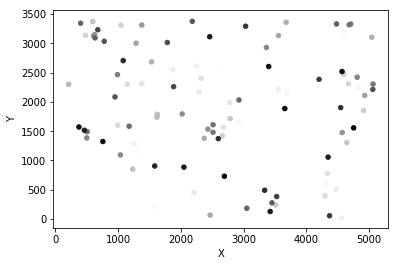

In [13]:
df_sample.plot(kind='scatter', x='X', y='Y', color=range(n_sample))

In [42]:
%time
def prime_range(lower, upper):
    primes = set([2])
    for num in range(lower,upper + 1):
        if num > 1:
            for p in primes:
                if (num % p) == 0:
                    break
            else:
                primes.add(num)
    return primes
primes = prime_range(2, len(df))

CPU times: user 6 µs, sys: 0 ns, total: 6 µs
Wall time: 13.6 µs


In [43]:
print(len(primes))

17802


In [65]:
dist_cache

{(22350, 137512): 1720.9543243635303,
 (137512, 22350): 1720.9543243635303,
 (109438, 89035): 1920.4996213552001,
 (89035, 109438): 1920.4996213552001}

In [132]:
dist_cache = {}
def distance(j, k):
    d = dist_cache.get((j, k), (((df.iloc[j].values - df.iloc[k].values)**2).sum())**0.5)
    dist_cache[(j, k)] = dist_cache[(k, j)] = d
    return d
    
def evaluate_path(path_tuples):
    dist_sum = 0
    path_dict = dict(path_tuples)
    j = 0
    for i in range(len(path_tuples)):
        k = path_dict[j]
        dist = distance(j, k)
        if k%10 == 0:
            if k in primes:
                dist_sum += dist
            else:
                # Add 10% to the distance if 
                dist_sum += dist*1.1
        else:
            dist_sum += dist
        j = k
    return dist_sum

def plot_eval(evaluation, ax=None):
    if ax:
        ax.plot(evaluation)

def plot_path(path_tuples, ax=None):
    path_dict = dict(path_tuples)
    j = 0
    path_list = [j]
    for i in range(len(path_tuples)):
        k = j = path_dict[j]
        path_list.append(k)
    df_subset = df.iloc[path_list]
    if ax:
        ax.plot(df_subset.X, df_subset.Y)

In [130]:
path = [0] + df_sample.index.tolist() + [0]
path_tuples = list(zip(path[:-1], path[1:]))
evaluation = []
print(path_tuples[:5])

[(0, 62198), (62198, 5823), (5823, 109438), (109438, 89035), (89035, 171994)]


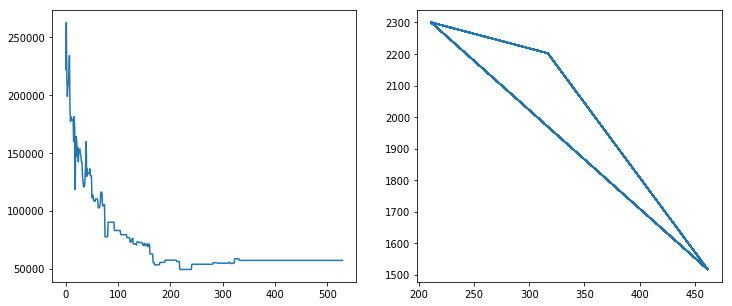

In [168]:
fig, axes = plt.subplots(1,2, figsize=(12,5))
for io in range(100):
    np.random.shuffle(path_tuples)
    better_path_tuples = []
    for ii in range(10):
        j, k = path_tuples.pop()
        l, m = path_tuples.pop()
        if j == m or l == k or distance(j, k) + distance(l, m) < distance(j, m) + distance(l, k):
            better_path_tuples.extend([(j, k), (l, m)])
        else:
            better_path_tuples.extend([(j, m), (l, k)])
    path_tuples.extend(better_path_tuples)
    evaluation.append(evaluate_path(path_tuples))
plot_eval(evaluation, ax=axes[0])
plot_path(path_tuples, ax=axes[1])

In [169]:
path_tuples

[(73010, 70706),
 (155541, 170919),
 (92692, 151863),
 (182635, 59772),
 (73430, 142401),
 (20930, 181062),
 (117741, 17891),
 (88513, 0),
 (2075, 151402),
 (42938, 171994),
 (137512, 31477),
 (151402, 48522),
 (195378, 183899),
 (109438, 22350),
 (98685, 155541),
 (95581, 37033),
 (83259, 178899),
 (49310, 74339),
 (12291, 103608),
 (79924, 126956),
 (162670, 92692),
 (147532, 2075),
 (1437, 48609),
 (101095, 170972),
 (74339, 49310),
 (31477, 137512),
 (1783, 132824),
 (156233, 51363),
 (59772, 128572),
 (195095, 42400),
 (183899, 195378),
 (183437, 92265),
 (103608, 12291),
 (135316, 167997),
 (66059, 84307),
 (148667, 182635),
 (99839, 5405),
 (171967, 140127),
 (5405, 99839),
 (48609, 109438),
 (128219, 100472),
 (62198, 1437),
 (29403, 88513),
 (170956, 127182),
 (52463, 65084),
 (151863, 73010),
 (84307, 147532),
 (142401, 183437),
 (163565, 13340),
 (126956, 79924),
 (127182, 170956),
 (178638, 4448),
 (181062, 195095),
 (3956, 117538),
 (178899, 98685),
 (108055, 61623),
 (117